# Analisis Tingkat Kematangan Buah Pisang dengan Segmentasi Warna HSV

**Nama:** Abiyu Neyad Meccada  
**NIM:** _(isi)_  
**Mata kuliah / Kelas:** _(isi)_

Notebook ini mengerjakan lima poin tugas:

1. Mengunggah dan menganalisis minimal 3 citra pisang dengan tingkat kematangan berbeda.
2. Segmentasi warna pada ruang warna HSV.
3. Membandingkan persentase warna hijau, kuning, dan cokelat tiap citra.
4. Grafik perbandingan persentase warna.
5. Analisis kesesuaian hasil klasifikasi dengan kondisi visual dan faktor yang memengaruhinya.

## 1. Unggah citra

Dua foto dipakai: satu foto pisang hijau (mentah) dan satu foto berisi tiga tandan (matang, matang berbintik, terlalu matang). Tiap tandan dipisahkan otomatis sehingga diperoleh **4 citra**.

Di Google Colab, sel di bawah menampilkan tombol unggah; pilih kedua foto sekaligus. Di Jupyter lokal, letakkan foto di folder yang sama dengan notebook. Citra diurutkan menurut nama file.

Foto yang dipakai: ['1_pisang_hijau.png', '2_pisang_tiga_tandan.jpg']


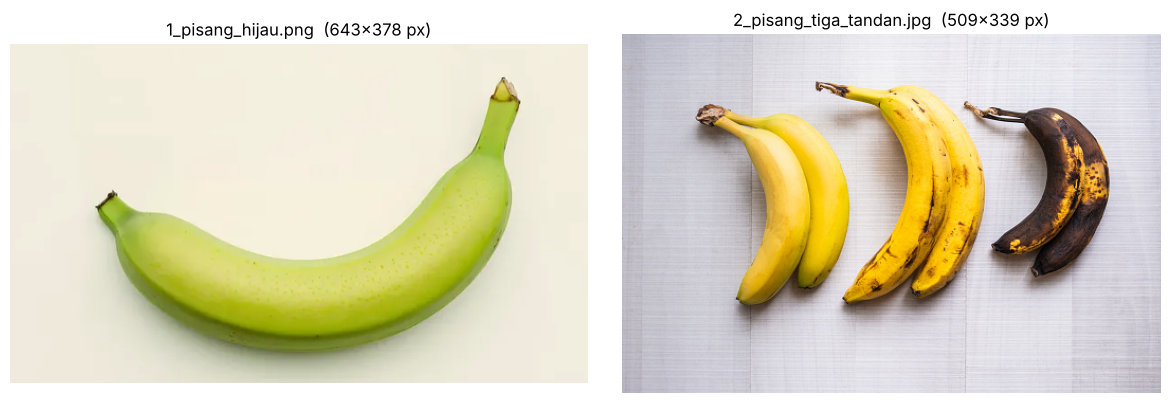

In [1]:
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import files
    berkas = sorted(files.upload().keys())
except ImportError:
    berkas = sorted(glob.glob("*pisang*.png") + glob.glob("*pisang*.jpg") + glob.glob("*pisang*.jpeg"))

print("Foto yang dipakai:", berkas)
foto = [cv2.imread(f) for f in berkas]

fig, ax = plt.subplots(1, len(foto), figsize=(6 * len(foto), 4), squeeze=False)
for a, f, nama in zip(ax[0], foto, berkas):
    a.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)); a.set_title(f"{nama}  ({f.shape[1]}x{f.shape[0]} px)"); a.axis("off")
plt.tight_layout(); plt.show()

### Memisahkan buah dari latar

Latar kedua foto berwarna terang dengan saturasi rendah, sedangkan pisang bersaturasi tinggi (hijau/kuning) atau gelap (cokelat). Jadi piksel buah diambil dengan syarat `S > 70` **atau** `V < 110`, dirapikan dengan operasi morfologi, lalu tiap komponen terhubung yang besar dijadikan satu citra. Persentase warna nantinya dihitung **hanya terhadap piksel buah**, bukan seluruh gambar.

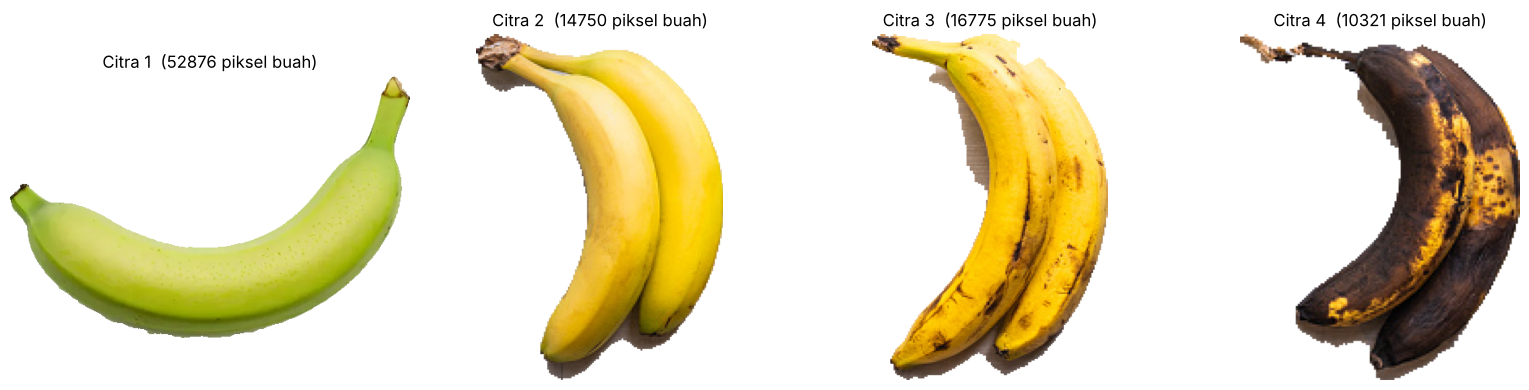

In [2]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
citra = []   # daftar (potongan BGR, potongan HSV, mask buah)

for f in foto:
    hsv = cv2.cvtColor(f, cv2.COLOR_BGR2HSV)
    S, V = hsv[..., 1], hsv[..., 2]
    fg = ((S > 70) | (V < 110)).astype(np.uint8) * 255
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)
    n, label, stats, _ = cv2.connectedComponentsWithStats(fg, 8)
    luas_maks = stats[1:, cv2.CC_STAT_AREA].max()
    besar = [i for i in range(1, n) if stats[i, cv2.CC_STAT_AREA] >= 0.3 * luas_maks]
    for i in sorted(besar, key=lambda i: stats[i, cv2.CC_STAT_LEFT]):      # kiri ke kanan
        x, y, w, h, _ = stats[i]
        buah = label[y:y+h, x:x+w] == i
        potong = f[y:y+h, x:x+w].copy()
        hsv_potong = hsv[y:y+h, x:x+w].copy()
        potong[~buah] = 255
        citra.append((potong, hsv_potong, buah))

nama_citra = [f"Citra {i+1}" for i in range(len(citra))]
fig, ax = plt.subplots(1, len(citra), figsize=(4 * len(citra), 4))
for a, (p, _, b), nm in zip(ax, citra, nama_citra):
    a.imshow(cv2.cvtColor(p, cv2.COLOR_BGR2RGB)); a.set_title(f"{nm}  ({b.sum()} piksel buah)"); a.axis("off")
plt.tight_layout(); plt.show()

## 2. Segmentasi warna pada ruang HSV

Ruang HSV memisahkan **rona (Hue)** dari **kecerahan (Value)**, sehingga warna bisa dipilih dengan rentang H tanpa terlalu terganggu terang-gelapnya gambar. Pada OpenCV, H bernilai 0–179, S dan V bernilai 0–255.

| Warna | Hue (H) | Saturation (S) | Value (V) |
|---|---|---|---|
| Hijau | 27 – 85 | ≥ 60 | ≥ 60 |
| Kuning | 18 – 26 | ≥ 90 | ≥ 140 |
| Cokelat | ≤ 35 atau ≥ 170 | ≥ 40 | < 140 |
| Cokelat kehitaman | bebas | bebas | < 60 |

Piksel yang sudah masuk hijau atau kuning tidak dihitung lagi sebagai cokelat. Batas hue hijau–kuning (26/27) dipilih dari sebaran hue citra ini; alasannya dibahas di bagian 5.

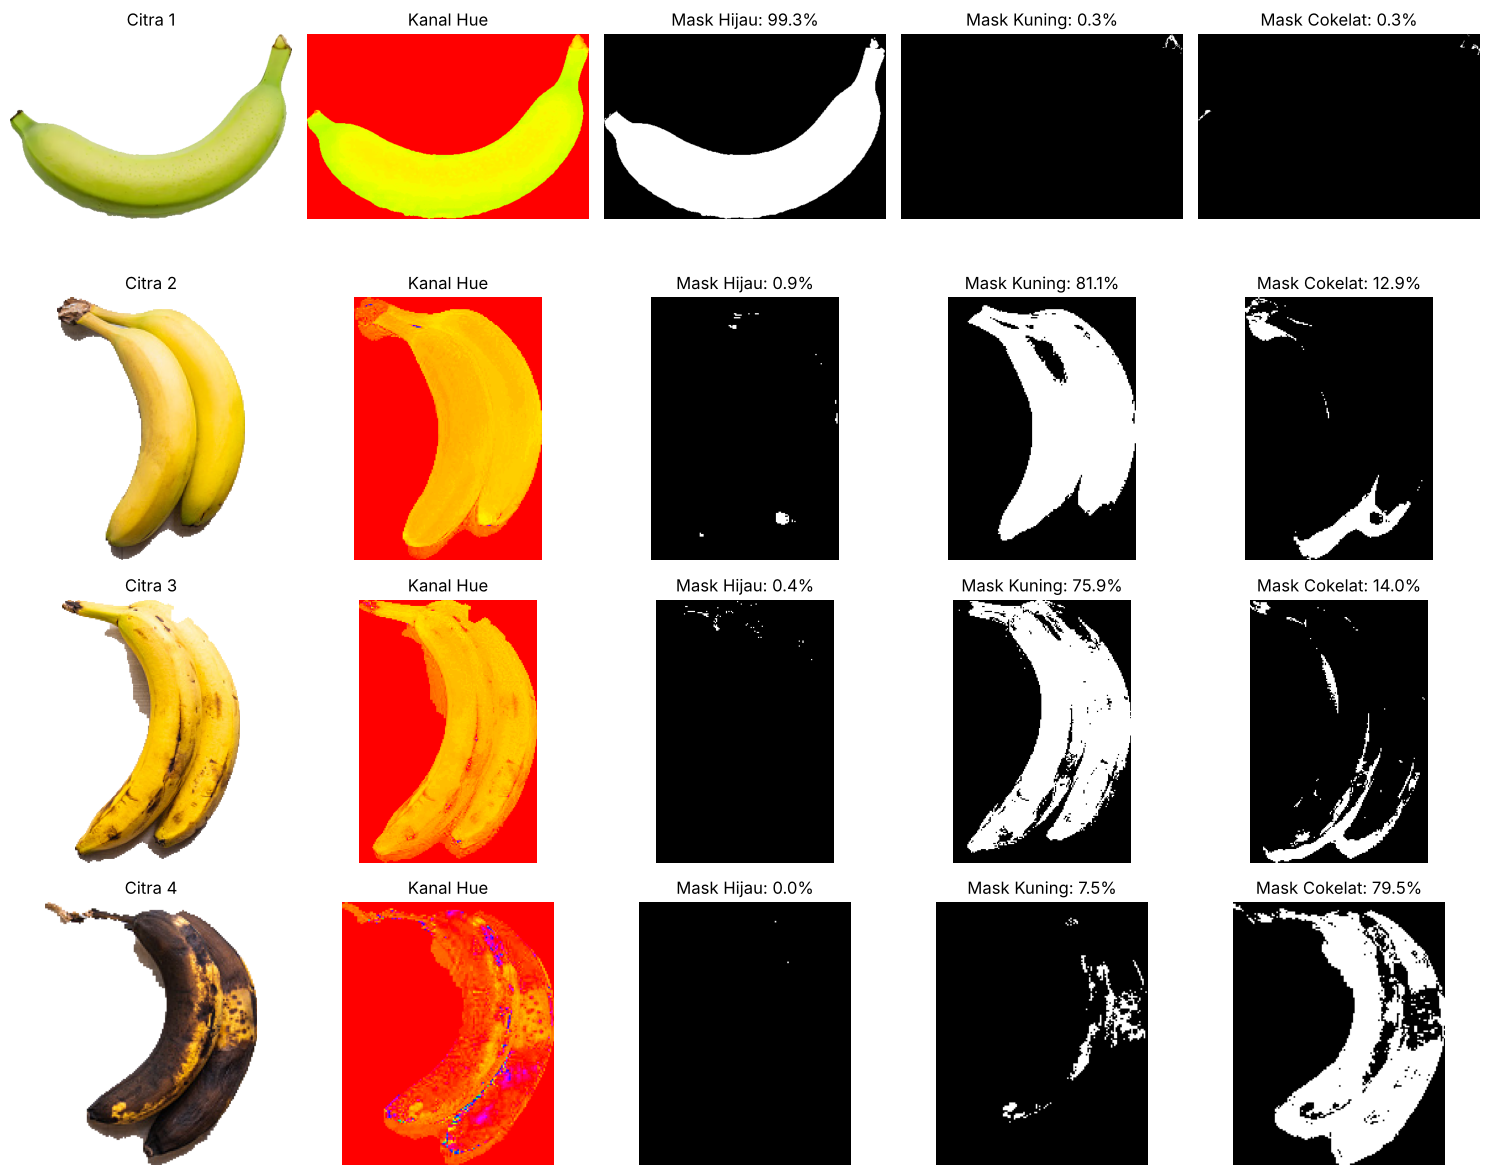

In [3]:
def segmentasi(hsv, batas_hijau=27):
    """Mengembalikan mask (hijau, kuning, cokelat). batas_hijau = hue terendah yang dianggap hijau."""
    h, s, v = cv2.split(hsv)
    hijau  = (h >= batas_hijau) & (h <= 85) & (s >= 60) & (v >= 60)
    kuning = (h >= 18) & (h < batas_hijau) & (s >= 90) & (v >= 140)
    cokelat = (((h <= 35) | (h >= 170)) & (s >= 40) & (v < 140)) | (v < 60)
    cokelat &= ~hijau & ~kuning
    return hijau, kuning, cokelat

def persentase(hsv, buah, batas_hijau=27):
    return [100 * (m & buah).sum() / buah.sum() for m in segmentasi(hsv, batas_hijau)]

N = len(citra)
fig, ax = plt.subplots(N, 5, figsize=(15, 3 * N))
for r, ((p, hsv, buah), nm) in enumerate(zip(citra, nama_citra)):
    pr = persentase(hsv, buah)
    ax[r, 0].imshow(cv2.cvtColor(p, cv2.COLOR_BGR2RGB)); ax[r, 0].set_title(nm)
    ax[r, 1].imshow(np.where(buah, hsv[..., 0], 0), cmap="hsv", vmin=0, vmax=179); ax[r, 1].set_title("Kanal Hue")
    for c, (m, t) in enumerate(zip(segmentasi(hsv), ("Hijau", "Kuning", "Cokelat"))):
        ax[r, 2 + c].imshow(m & buah, cmap="gray"); ax[r, 2 + c].set_title(f"Mask {t}: {pr[c]:.1f}%")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.show()

## 3. Perbandingan persentase warna

Aturan klasifikasi: warna dengan persentase terbesar menentukan kelas (hijau = mentah, kuning = matang, cokelat = terlalu matang). Jika kuning dominan tetapi cokelat ≥ 5%, kelasnya **matang lanjut (mulai berbintik)**. Kolom *Lain-lain* adalah piksel buah yang tidak masuk ketiga rentang, misalnya pantulan cahaya yang pucat.

In [4]:
def klasifikasi(hijau, kuning, cokelat):
    kelas = ["Mentah", "Matang", "Terlalu matang/busuk"][int(np.argmax([hijau, kuning, cokelat]))]
    if kelas == "Matang" and cokelat >= 5:
        kelas = "Matang lanjut (mulai berbintik)"
    return kelas

baris = []
for (p, hsv, buah), nm in zip(citra, nama_citra):
    g, k, c = persentase(hsv, buah)
    baris.append({"Citra": nm, "Piksel buah": int(buah.sum()), "Hijau (%)": g, "Kuning (%)": k,
                  "Cokelat (%)": c, "Lain-lain (%)": 100 - g - k - c, "Klasifikasi": klasifikasi(g, k, c)})
tabel = pd.DataFrame(baris).set_index("Citra")
tabel.round(2)

,Piksel buah,Hijau (%),Kuning (%),Cokelat (%),Lain-lain (%),Klasifikasi
Citra,,,,,,
Citra 1,52876,99.28,0.31,0.31,0.10,Mentah
Citra 2,14750,0.88,81.13,12.92,5.07,Matang lanjut (mulai berbintik)
Citra 3,16775,0.43,75.94,14.01,9.62,Matang lanjut (mulai berbintik)
Citra 4,10321,0.02,7.55,79.46,12.97,Terlalu matang/busuk


## 4. Grafik perbandingan

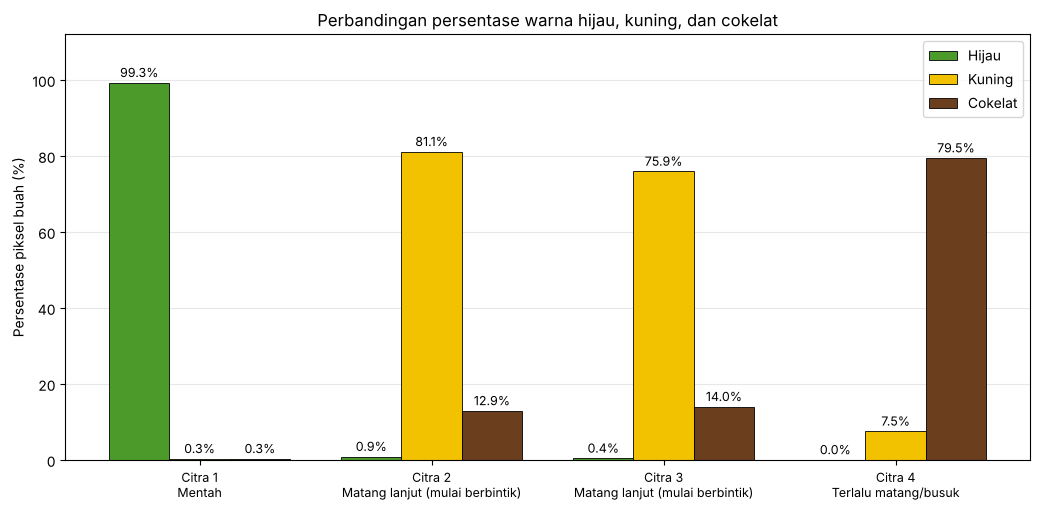

In [5]:
warna = {"Hijau (%)": "#4c9a2a", "Kuning (%)": "#f2c200", "Cokelat (%)": "#6b3e1e"}
x = np.arange(len(tabel)); lebar = 0.26
fig, ax = plt.subplots(figsize=(10.5, 5.2))
for j, (kolom, w) in enumerate(warna.items()):
    batang = ax.bar(x + (j - 1) * lebar, tabel[kolom], lebar, label=kolom.replace(" (%)", ""), color=w, edgecolor="black", linewidth=0.6)
    ax.bar_label(batang, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f"{i}\n{k}" for i, k in zip(tabel.index, tabel["Klasifikasi"])], fontsize=9)
ax.set_ylabel("Persentase piksel buah (%)"); ax.set_ylim(0, 112)
ax.set_title("Perbandingan persentase warna hijau, kuning, dan cokelat")
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 5. Analisis

### Percobaan pendukung: pengaruh batas hue hijau

Banyak referensi memakai rentang hijau H 36–85. Sel berikut membandingkan rentang itu dengan rentang yang dipakai di notebook ini (H 27–85), dan menampilkan sebaran hue piksel terang tiap citra.

In [6]:
banding = []
for (p, hsv, buah), nm in zip(citra, nama_citra):
    terang = buah & (hsv[..., 1] > 90) & (hsv[..., 2] >= 140)
    q5, q50, q95 = np.percentile(hsv[..., 0][terang], [5, 50, 95])
    a = persentase(hsv, buah, batas_hijau=36); b = persentase(hsv, buah, batas_hijau=27)
    banding.append({"Citra": nm, "Hue persentil 5": q5, "Hue median": q50, "Hue persentil 95": q95,
                    "Hijau % (H>=36)": a[0], "Kuning % (H>=36)": a[1], "Kelas (H>=36)": klasifikasi(*a),
                    "Hijau % (H>=27)": b[0], "Kuning % (H>=27)": b[1], "Kelas (H>=27)": klasifikasi(*b)})
pd.DataFrame(banding).set_index("Citra").round(1)

,Hue persentil 5,Hue median,Hue persentil 95,Hijau % (H>=36),Kuning % (H>=36),Kelas (H>=36),Hijau % (H>=27),Kuning % (H>=27),Kelas (H>=27)
Citra,,,,,,,,,
Citra 1,29.0,32.0,36.0,11.0,76.3,Matang lanjut (mulai berbintik),99.3,0.3,Mentah
Citra 2,20.0,23.0,25.0,0.0,81.4,Matang lanjut (mulai berbintik),0.9,81.1,Matang lanjut (mulai berbintik)
Citra 3,17.0,23.0,25.0,0.0,76.3,Matang lanjut (mulai berbintik),0.4,75.9,Matang lanjut (mulai berbintik)
Citra 4,10.0,17.0,22.0,0.0,7.6,Terlalu matang/busuk,0.0,7.5,Terlalu matang/busuk


### Kesesuaian hasil klasifikasi dengan kondisi visual

| Citra | Kondisi visual | Klasifikasi program | Sesuai? |
|---|---|---|---|
| Citra 1 | Mentah, hijau merata | Mentah (hijau 99,3%) | Ya |
| Citra 2 | Matang segar, kulit kuning mulus | Matang lanjut (kuning 81,1%, cokelat 12,9%) | **Tidak** |
| Citra 3 | Matang lanjut, ada bintik dan garis cokelat | Matang lanjut (kuning 75,9%, cokelat 14,0%) | Ya |
| Citra 4 | Terlalu matang, kulit hampir seluruhnya cokelat-hitam | Terlalu matang/busuk (cokelat 79,5%) | Ya |

Tiga dari empat citra terklasifikasi sesuai kondisi visualnya.

- **Citra 1** sesuai: hampir seluruh piksel buah masuk rentang hijau.
- **Citra 4** sesuai: cokelat dominan, dan sisa kuning 7,5% cocok dengan bercak kuning yang masih terlihat di sisi kanan buah.
- **Citra 3** sesuai: kuning masih dominan dan mask cokelat mengikuti garis serta bintik pada kulit.
- **Citra 2** tidak sesuai: kulitnya mulus, tetapi 12,9% pikselnya terbaca cokelat. Pada mask terlihat bahwa piksel itu berada di bagian bawah buah yang terkena bayangan dan di tangkai, bukan bintik pembusukan. Akibatnya angka cokelat Citra 2 (12,9%) hampir sama dengan Citra 3 (14,0%), sehingga persentase warna saja belum bisa membedakan "matang segar" dari "matang berbintik".

### Faktor yang memengaruhi hasil

1. **Pemilihan rentang hue.** Hijau pisang mentah adalah hijau kekuningan dengan hue sekitar 29–36, sedangkan pisang kuning di foto ini berada di sekitar 20–25. Dengan rentang hijau H ≥ 36, Citra 1 terbaca 76% kuning dan salah diklasifikasikan; setelah batas digeser ke 27, hasilnya benar (lihat tabel percobaan di atas). Batas ini disetel dari empat citra ini saja, sehingga belum tentu cocok untuk foto lain.
2. **Pencahayaan dan bayangan.** Kuning yang gelap karena bayangan memiliki hue yang sama dengan cokelat dan hanya berbeda pada nilai V, sehingga ikut terhitung cokelat. Ini penyebab kesalahan pada Citra 2.
3. **Ambang Value.** Batas V = 140 antara kuning dan cokelat ditentukan manual; menggesernya mengubah persentase kedua warna.
4. **Pantulan cahaya.** Bagian kulit yang mengilap menjadi pucat (saturasi rendah) dan masuk ke *Lain-lain*, sebesar 5–13% pada Citra 2–4.
5. **Pemisahan latar.** Tangkai dan sisa bayangan di tepi objek ikut terhitung sebagai piksel buah.
6. **Resolusi dan kompresi.** Foto tiga tandan hanya 509×339 piksel berformat JPEG, sehingga bintik kecil pada Citra 3 sebagian membaur dengan warna sekitarnya.
7. **Kondisi pemotretan berbeda.** Kedua foto diambil dengan pencahayaan, latar, dan kamera yang berbeda, sehingga perbandingan antarcitra tidak sepenuhnya setara.
8. **Aturan klasifikasi sederhana.** Kelas ditentukan dari proporsi warna saja, tanpa melihat bentuk atau sebaran bintik.

### Kesimpulan

Segmentasi warna HSV mampu membedakan pisang mentah, matang, dan terlalu matang dengan jelas melalui pergeseran warna dominan dari hijau ke kuning lalu ke cokelat. Metode ini kurang andal untuk membedakan tingkat kematangan yang berdekatan (matang segar dan matang berbintik), karena bayangan terbaca sebagai cokelat. Hasil dapat diperbaiki dengan pencahayaan merata, latar seragam, resolusi lebih tinggi, dan ambang yang disetel dari lebih banyak sampel.